In [1]:
from GraphtoMatrix import get_matrix
from GraphtoMatrix import get_matrix_new
# from individual import gen_daccad_individuals, standard_init_ind, DaccadIndividual
import submitDACCAD
from ReservoirRun import Reservoir
import numpy as np
from numpy import linalg as LA
import os
from datetime import datetime
from evolver import DaccadBioneatMut
from qdpy.containers import *
from individual import *

In [2]:
testArray = np.array([1.0, 10.0, 0.5, 0., 0., 0.5, 0., 0., 0., 1.0, 1.0, 0., 0., 0.])
matrix = get_matrix(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print(w, v)

[[ 1. -1.]
 [-1.  1.]]
[2. 0.] [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [3]:
testArray = np.array([1.0, 10.0, 0.5, 0., 0., 0.5, 0., 0., 0., 1.0, 1.0, 0., 0., 0.])
matrix = get_matrix_new(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print(w, v)

[[ 0.9 -1. ]
 [-1.   0.9]]
[ 1.9 -0.1] [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [4]:
testArray = np.array([1.0, 10.0, 0, 0.5, 0.5, 0, 0., 0., 0., 0, 0, 0., 0., 0.])
matrix = 0.5 * get_matrix(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print(w, v)

[[0.  0.5]
 [0.5 0. ]]
[ 0.5 -0.5] [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [5]:
testArray = np.array([1.0, 10.0, 0, 0.5, 0.5, 0, 0., 0., 0., 0, 0, 0., 0., 0.])
matrix = 0.5 * get_matrix_new(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print(w, v)

[[-0.05  0.5 ]
 [ 0.5  -0.05]]
[ 0.45 -0.55] [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [6]:
testArray = np.array([1.0, 10.0, 0.5, 0.5, 0, 0, 0., 0., 0., 0, 0.5, 0., 0., 0.])
matrix = get_matrix(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print("w = ", w)
w = np.linalg.norm(w[1])
print(w, v)

[[ 1.  1.]
 [-1.  0.]]
w =  [0.5+0.8660254j 0.5-0.8660254j]
0.9999999999999999 [[ 0.35355339+0.61237244j  0.35355339-0.61237244j]
 [-0.70710678+0.j         -0.70710678-0.j        ]]


In [7]:
testArray = np.array([1.0, 10.0, 0.5, 0.5, 0, 0, 0., 0., 0., 0, 0.5, 0., 0., 0.])
matrix = get_matrix_new(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print("w = ", w)
w = np.linalg.norm(w[1])
print(w, v)

[[ 0.9  1. ]
 [-1.  -0.1]]
w =  [0.4+0.8660254j 0.4-0.8660254j]
0.9539392014169454 [[ 0.70710678+0.j          0.70710678-0.j        ]
 [-0.35355339+0.61237244j -0.35355339-0.61237244j]]


In [8]:
testArray = np.array([1.0, 10.0, 0, 0.5, 0, 0, 0., 0., 0., 0, 0, 0., 0., 0.])
matrix = get_matrix(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print("w = ", w)
w = np.linalg.norm(w)
print(w, v)

[[0.]]
w =  [0.]
0.0 [[1.]]


In [9]:
testArray = np.array([1.0, 10.0, 0, 0.5, 0, 0, 0., 0., 0., 0, 0, 0., 0., 0.])
matrix = get_matrix_new(testArray, 2)
print(matrix)
w, v = LA.eig(matrix)
print("w = ", w)
w = np.linalg.norm(w)
print(w, v)

[[-0.1  1. ]
 [ 0.  -0.1]]
w =  [-0.1 -0.1]
0.14142135623730953 [[ 1.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  2.22044605e-17]]


In [10]:
eigenvalues = []
mc_lst = []

for i in range(1):
    base = gen_daccad_individuals([0., 1.])
    daccadIndiv = standard_init_ind(base)
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = daccadIndiv.nb_nodes
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    myarray = np.array(scaling)*np.array(daccadIndiv)
    matrix = get_matrix(myarray, nNodes)
    w, v = LA.eig(matrix)
    print("myarray : ", myarray)
    print(w, v)
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                 configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                 jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                 configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                 ).decode('ascii')
    mc = 0
    k_max = 10
    for k in range(1, k_max + 1):
        Reservoir_mc = Reservoir(ind=myarray, nNodes=nNodes, result=jikeiretu, delay=k)
        data = Reservoir_mc.get_data()
        X, Y = Reservoir_mc.run(data)
        mc_k = Reservoir_mc.get_MCk(data, Y)
        mc += mc_k
    print(mc)
    eigenvalues.append(np.linalg.norm(w[0]))
    mc_lst.append(mc)

In [1]:
grid = Grid(shape=(10,10), max_items_per_bin=1, fitness_domain=((0., 1.),), features_domain=((0., 1.), (0., 1.)))

for _ in range(100):
    evo = DaccadBioneatMut(grid, 10, [0.0,200.0])
    
    indiv = evo.ask()
    print(indiv)
    
    daccadIndiv = indiv
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = daccadIndiv.nb_nodes
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    myarray = np.array(scaling)*np.array(daccadIndiv)
    matrix = get_matrix(myarray, nNodes)
    w, v = LA.eig(matrix)
    print("myarray : ", myarray)
    print(w, v)
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                 configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                 jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                 configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                 ).decode('ascii')
    mc = 0
    k_max = 10
    for k in range(1, k_max + 1):
        Reservoir_mc = Reservoir(ind=myarray, nNodes=nNodes, result=jikeiretu, delay=k)
        data = Reservoir_mc.get_data()
        X, Y = Reservoir_mc.run(data)
        mc_k = Reservoir_mc.get_MCk(data, Y)
        mc += mc_k
    print(mc)
    eigenvalues.append(np.mean([np.linalg.norm(val) for val in w]))
    mc_lst.append(mc)

NameError: name 'Grid' is not defined

In [14]:
print(mc_lst, eigenvalues)

[1.3362199604441765, 9.00597188005091, 8.730738677954351, 8.444741786105647, 8.210464794924638, 8.603608798562602, 8.554860209302602, 0.012698347211298451, 0.20451180988026407, 8.992432889780675, 8.093864823642349, 8.68730772426042, 9.00183405993713, 8.267431982690793, 8.884600342526564, 8.521421387972781, 8.913901991401428, 8.845756370583906, 8.558950728087975, 8.473313198131251, 8.500390576496107, 8.91700777749453, 9.32694365718973, 8.788217448382008, 8.459171751252613, 8.714535364635129, 9.178930845040348, 8.537975966329217, 8.174933851719295, 8.611788388685076, 8.543589218424229, 8.516198479732429, 8.481979360010325, 8.632952515707132, 8.773041731271434, 8.271652874592808, 8.983967670283402, 8.464505143472165, 7.956191852564125, 8.258283542536144, 0.018772273502201463, 8.758979726973475, 8.915057235335109, 9.090514132888963, 8.153483658760127, 0.06233877246512183, 0.4866097440656932, 8.211850549445964, 9.065695722203117, 7.913499148135908, 8.331053633840654, 8.319075358633215, 8.47

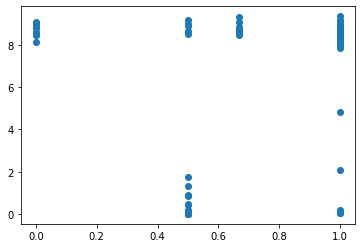

In [18]:
import matplotlib.pyplot as plt
plt.scatter(eigenvalues, mc_lst)

In [11]:
eigenvalues_new = []
mc_lst_new = []

In [12]:
grid = Grid(shape=(10,10), max_items_per_bin=1, fitness_domain=((0., 1.),), features_domain=((0., 1.), (0., 1.)))

for _ in range(100):
    evo = DaccadBioneatMut(grid, 10, [0.0,200.0])

    indiv = evo.ask()
    print(indiv)
    
    daccadIndiv = indiv
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = daccadIndiv.nb_nodes
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    myarray = np.array(scaling)*np.array(daccadIndiv)
    matrix = get_matrix_new(myarray, nNodes)
    w, v = LA.eig(matrix)
    print("myarray : ", myarray)
    print(w, v)
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                 configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                 jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                 configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                 ).decode('ascii')
    mc = 0
    k_max = 10
    for k in range(1, k_max + 1):
        Reservoir_mc = Reservoir(ind=myarray, nNodes=nNodes, result=jikeiretu, delay=k)
        data = Reservoir_mc.get_data()
        X, Y = Reservoir_mc.run(data)
        mc_k = Reservoir_mc.get_MCk(data, Y)
        mc += mc_k
    print(mc)
    eigenvalues_new.append(np.mean([np.linalg.norm(val) for val in w]))
    mc_lst_new.append(mc)

DaccadIndividual([0.01, 0.01, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.14858942958847793, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05027171010685691, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [ 10.          10.         100.           0.           0.
   0.           0.           0.          29.71788592   0.
   0.           5.           0.           0.           0.
   0.           0.          10.05434202   0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.        ]
[-0.1 -0.1  0.9] [[ 1.          0.         -0.57735027]
 [ 0.          1.          0.57735027]
 [ 0.          0.          0.57735027]]
8.316620259178451
DaccadIndividual([0.0051, 0.020892351503525062, 0.14711615330697042, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.014162463674163

0.35176608758630074
DaccadIndividual([0.00801632371413553, 0.008512584747567374, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.035281867386771776, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [  8.01632371   8.51258475 100.           0.           0.
   0.           0.           0.           0.           0.
   0.           7.05637348   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.        ]
[-0.1 -0.1  0.9] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
8.271765204030853
DaccadIndividual([0.01, 0.01, 0.1, 0.6779619447039266, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.3432080444908159, 0.0, 0.0, 0.015114302027028983, 0.0,

8.186371253549595
DaccadIndividual([0.01, 0.012362063020098705, 0.12352096618373377, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [ 10.          12.36206302 123.52096618   0.           0.
   0.           0.           0.           0.           0.
   0.           5.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.        ]
[-0.1 -0.1  0.9] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
8.252737711633287
DaccadIndividual([0.01, 0.01, 0.1, 0.020743405081552896, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.03423540703171055, 0.0, 0.16316858337990892, 0.0, 0.0, 0.0, 0.0

8.844065829227153
DaccadIndividual([0.01, 0.01, 0.1, 0.0, 84.43382210438281, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [1.00000000e+01 1.00000000e+01 1.00000000e+02 0.00000000e+00
 1.68867644e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[-0.1 -0.1  0.9] [[ 1.00000000e+00 -1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.22044605e-17  0.00000000e+00]
 [ 0.00000000e+00  0.000

8.664826064740712
DaccadIndividual([0.01, 0.01, 0.1, 0.039075695096826665, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03857440943218772, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [ 10.          10.         100.           7.81513902   0.
   0.           0.           0.           0.           0.
   0.           5.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   7.71488189   0.           0.           0.           0.
   0.           0.           0.           0.        ]
[ 0.9  0.9 -0.1] [[0.00000000e+00 1.99840144e-16 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [1.00000000e+00 1.00000000e+00 0.00000000e+00]]
9.013719595795386
DaccadIndividual([0.01, 0.01, 0.1, 0.0, 0.0, 0.0, 82.95200098921704, 0.0, 0.0, 0

...

8.488763527000405
DaccadIndividual([0.01, 0.01, 0.1, 0.228722515256934, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [ 10.          10.         100.         228.72251526   0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   5.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.      

8.402114358213
DaccadIndividual([0.01, 0.01, 0.1, 0.0, 129.5466504572532, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [1.00000000e+01 1.00000000e+01 1.00000000e+02 0.00000000e+00
 2.59093301e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[-0.1 -0.1  0.9] [[ 1.00000000e+00 -1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.22044605e-17  0.00000000e+00]
 [ 0.00000000e+00  0.000000

8.451642107513255
DaccadIndividual([0.01, 0.01, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 181.9159009299736, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
myarray :  [1.00000000e+01 1.00000000e+01 1.00000000e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.63831802e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[-0.1 -0.1  0.9] [[ 1.          0.         -0.70710678]
 [ 0.          1.          0.        ]
 [ 0.          0.          0.70710678]]


/home/mika/Documents/daccadevo/scripts/submitDACCAD.py:194: RuntimeWarning: ERROR during DACCAD execution with command: ['../../daccad/cli.sh', 'cli.CLIEvaluatorwithInput', '/home/mika/Documents/daccadevo/scripts/../daccadConf.conf', '/home/mika/Documents/daccadevo/scripts/./2021-12-13T12:57:09.208632.json', '/home/mika/Documents/daccadevo/scripts/../config_mc.json']
  warnings.warn("ERROR during DACCAD execution with command: %s" % str(command), RuntimeWarning)


AttributeError: 'NoneType' object has no attribute 'decode'

[8.316620259178451, 8.660007312661728, 1.3818034313556191, 8.703547614163318, 8.330274182429324, 8.746741344671918, 8.888950407581397, 9.311226282410287, 0.35176608758630074, 8.271765204030853, 8.778997336501721, 0.2512571291368768, 8.12751012200243, 8.601255908651506, 8.301446638347846, 8.586960928694657, 1.1566654524423907, 8.186371253549595, 8.252737711633287, 8.585786942939041, 1.1099007958476237, 8.351651155542664, 8.20919457715509, 0.005117311729879661, 0.03124154025032717, 8.844065829227153, 0.037965172817731194, 8.56174298981587, 8.460923917470964, 8.56846011054608, 8.104533480165683, 8.2961920970452, 8.82543855216404, 8.664826064740712, 9.013719595795386, 0.3791193922375012, 0.17785854050502325, 9.02875462695478, 8.885530292560059, 0.07740623373041812, 9.155290194050888, 8.836956737307798, 8.627105265173018, 8.703635374063873, 8.785608915955613, 8.514927970491922, 8.20758130021219, 8.121911562616226, 0.6598697314164045, 0.1648038016363883, 8.328103047322852, 7.9459650499841885

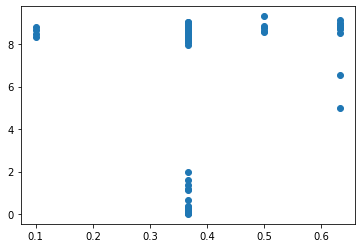

In [13]:
print(mc_lst_new, eigenvalues_new)
import matplotlib.pyplot as plt
plt.scatter(eigenvalues_new, mc_lst_new)